In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.optimize import linprog, linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import pickle as pkl
import os
import math
from itertools import permutations
warnings.simplefilter("ignore")

In [4]:
from mtu_plots import graph_metrics_and_models, transform_relative_to_ideal
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [5]:
DEBUG = True

In [6]:
model_keys = [
    #"ideal",
    "content_5",
    #"content_10",
    #"pop",
    "mf",
    #"sf",
    #"random"
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    "trait_history",
    "rank_history",
    ]

feed_names = [
    "rs_feed",
    "rand_feed",
    "pop_feed",
    "trend_feed",
    "new_feed",
    "social_feed",
    ]

In [7]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})

rs_colors = {
    'ideal' : 'tab:blue',
    'content_5' : 'mediumseagreen',
    'content_10' : 'tab:orange',
    'pop' : 'tab:red',
    'sf' : 'chocolate',
    'mf' : 'mediumorchid',
    'random' : 'tab:pink',
}

feed_colors = {
    "rs_feed": "cornflowerblue",
    "rand_feed": "magenta",
    "pop_feed": "red",
    "trend_feed": "orange",
    "new_feed": "purple",
    "social_feed": "saddlebrown",
}
indexable_feed_colors = np.array(list(feed_colors.values()))

# readable legend keys
model_to_readable = {
    "ideal": "Ideal",
    "content_5": "Content-based Filtering",
    "content_10": "Content Filtering 10 Tags",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

feed_names_to_readable = {
    "rs_feed": "Algorithmic Feed",
    "rand_feed": "Random Feed",
    "pop_feed": "Popular Feed",
    "trend_feed": "Trending Feed",
    "new_feed": "News Feed",
    "social_feed": "Social Feed",
    "ideal_feed": "Ideal Feed",
}

In [8]:
folder_paths = ["/home/salveal/data/salveal/results21/dynamic"]
inpi = 40
last_iter = 180

In [9]:
final_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_results[metric_name][model_name] += np.array(metric_vals).tolist()
user_prefs = np.array(final_results['user_prefs']['all'])
item_attrs = np.array(final_results['item_attrs']['all'])

In [10]:
interactions = dict()
for mo in model_keys:
    interactions[mo] = np.array(final_results['interaction_history'][mo])
    interactions[mo] = np.transpose(interactions[mo].reshape(interactions[mo].shape[:-1]), axes=[0,2,1])

In [11]:
decisions = dict()
for mo in model_keys:
    decisions[mo] = np.array(final_results['decisions'][mo])
    decisions[mo] = np.transpose(decisions[mo], axes=[0,2,1])

In [12]:
utilities = dict()
for mo in model_keys:
    utilities[mo] = np.array(final_results['utility_history'][mo])
    utilities[mo] = np.transpose(utilities[mo], axes=[0,2,1])

In [13]:
traits = dict()
for mo in model_keys:
    traits[mo] = np.array(final_results['trait_history'][mo])
    traits[mo] = np.transpose(traits[mo], axes=[0,2,1,3])

In [14]:
ranks = dict()
for mo in model_keys:
    ranks[mo] = np.array(final_results['rank_history'][mo])
    ranks[mo] = np.transpose(ranks[mo], axes=[0,2,1])

In [15]:
util_ranks = dict()
for mo in model_keys:
    util_ranks[mo] = np.array(final_results['utility_rank_history'][mo])
    util_ranks[mo] = np.transpose(util_ranks[mo], axes=[0,2,1])

In [16]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from sklearn.metrics import davies_bouldin_score

In [17]:
folder_paths_base = ["/home/salveal/data/salveal/results21/base"]

In [18]:
final_base_results = defaultdict(lambda: defaultdict(list))
for folder_path in folder_paths_base:
    filepath = os.path.join(folder_path, "sim_results.pkl")
    results = pkl.load(open(filepath, "rb"))
    for metric_name, v in results.items():
        for model_name, metric_vals in v.items():
            final_base_results[metric_name][model_name] += np.array(metric_vals).tolist()
#user_prefs = np.array(final_base_results['user_prefs']['all'])
base_item_attrs = np.array(final_base_results['item_attrs']['all'])

In [119]:
base_interactions = dict()
for mo in model_keys + ['ideal']:
    base_interactions[mo] = np.array(final_base_results['interaction_history'][mo])
    base_interactions[mo] = np.transpose(base_interactions[mo].reshape(base_interactions[mo].shape[:-1]), axes=[0,2,1])

In [20]:
base_decisions = dict()
for mo in model_keys:
    base_decisions[mo] = np.array(final_base_results['decisions'][mo])
    base_decisions[mo] = np.transpose(base_decisions[mo], axes=[0,2,1])

In [21]:
base_utilities = dict()
for mo in model_keys:
    base_utilities[mo] = np.array(final_base_results['utility_history'][mo])
    base_utilities[mo] = np.transpose(base_utilities[mo], axes=[0,2,1])

In [22]:
base_utilities["content_5"].shape
utilities["content_5"].mean()

0.24551553500680015

## Distribución de Feeds

In [23]:
traits[mo].shape # (sims=30, users=200, iters=200, traits=7)

(30, 200, 200, 7)

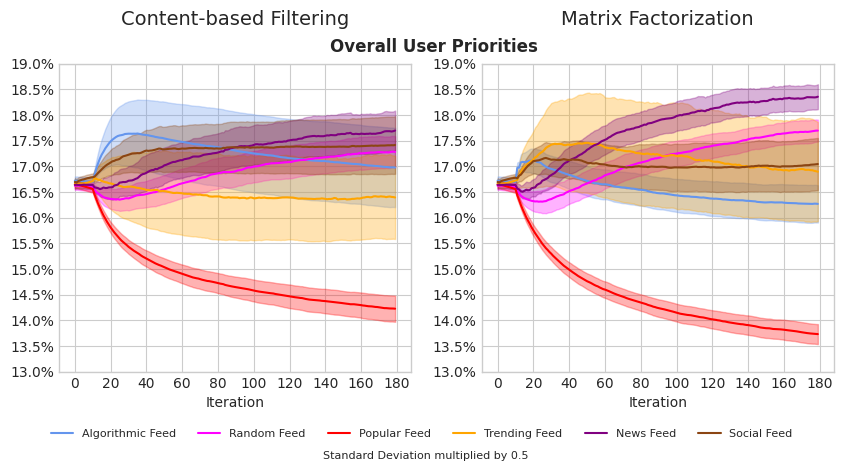

In [24]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

col=-1
upper_ylim = -10.0
lower_ylim = 10.0

for mo in model_keys:
    col += 1
    for feed_i in range(len(feed_names)):
        ax = axes[col]
        y_axis = traits[mo][:,:,:last_iter,feed_i].mean(axis=1) # (sims=30, iters=180)
        values = gaussian_filter1d(y_axis.mean(axis=0), sigma=0.1)
        line = ax.plot(values, label=feed_names_to_readable[feed_names[feed_i]], color=feed_colors[feed_names[feed_i]])
        
        #feed_legend_handles.append(line[0])
        #feed_legend_labels.append(feed_names[feed_i])

        std = y_axis.std(axis=0)
        mtus = np.arange(len(std))
        low = values - 0.5 * std
        high = values + 0.5 * std
        low = gaussian_filter1d(low, sigma=0.1)
        high = gaussian_filter1d(high, sigma=0.1)
        ax.fill_between(mtus, low, high, color=feed_colors[feed_names[feed_i]], alpha=0.3)

        upper_ylim = max(high.max(), upper_ylim)
        lower_ylim = min(low.min(), lower_ylim)

upper_ylim = np.round(upper_ylim, 2) + 0.01
lower_ylim = np.round(lower_ylim, 2) - 0.01
col=-1
for mo in model_keys:
    col+=1
    ax = axes[col]
    ax.set_ylim((0.13, 0.19))
    ax.set_yticks(np.arange(0.13, 0.195, 0.005))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{np.round(x*100,2)}%"))
    ax.set_xlabel("Iteration")
    ax.set_xticks(np.arange(0, 181, 20))

fig.text(
    x=0.5,
    y=0.9,
    s="Overall User Priorities",
    ha='center',
    va='bottom', 
    fontsize=12, 
    fontweight='bold',
)

for ax, col in zip(axes, model_keys):
    ax.set_title(model_to_readable[col], fontsize=14, pad=28.0)

ax.legend(loc='lower center', bbox_to_anchor=(-0.17, -0.25), ncol=6, fontsize=8)
plt.text(x=-40.4, y=0.113, s="Standard Deviation multiplied by 0.5", ha='center', fontsize=8)
plt.show()

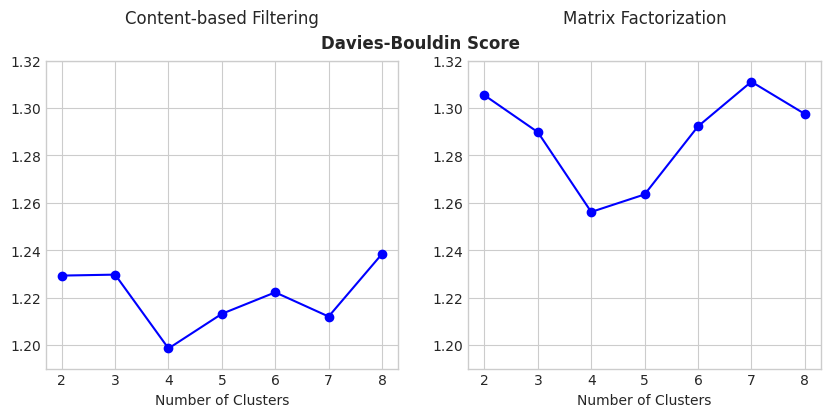

In [25]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

col = -1
iter_index = last_iter - 1
opt_k = dict()
for mo in model_keys:
    col+=1
    opt_db = 1000
    db = []
    kmax = 8
    number_of_clusters = list(range(2, kmax+1))
    # dissimilarity would not be defined for a single cluster, thus, minimum number of clusters should be 2
    for k in number_of_clusters:
        db_i = []
        for i in range(traits[mo].shape[0]): # iteramos por las simulaciones
            data = traits[mo][i,:,iter_index,:-1] # (users=200, traits=6)
            kmeans = KMeans(n_clusters = k, random_state=1234).fit(data)
            labels = kmeans.labels_
            db_i.append(davies_bouldin_score(data, labels))
        db.append(np.mean(db_i))
        if  opt_db > db[-1]:
            opt_db = db[-1]
            opt_k[mo] = k
    ax = axes[col]
    ax.plot(number_of_clusters, db, 'bo-')
    ax.set_ylim((1.19, 1.32))
    ax.set_title(model_to_readable[mo], pad=27.0)
    ax.set_xlabel("Number of Clusters")
fig.text(
    x=0.5,
    y=0.9,
    s="Davies-Bouldin Score",
    ha='center',
    va='bottom', 
    fontsize=12, 
    fontweight='bold',
)
fig.show()

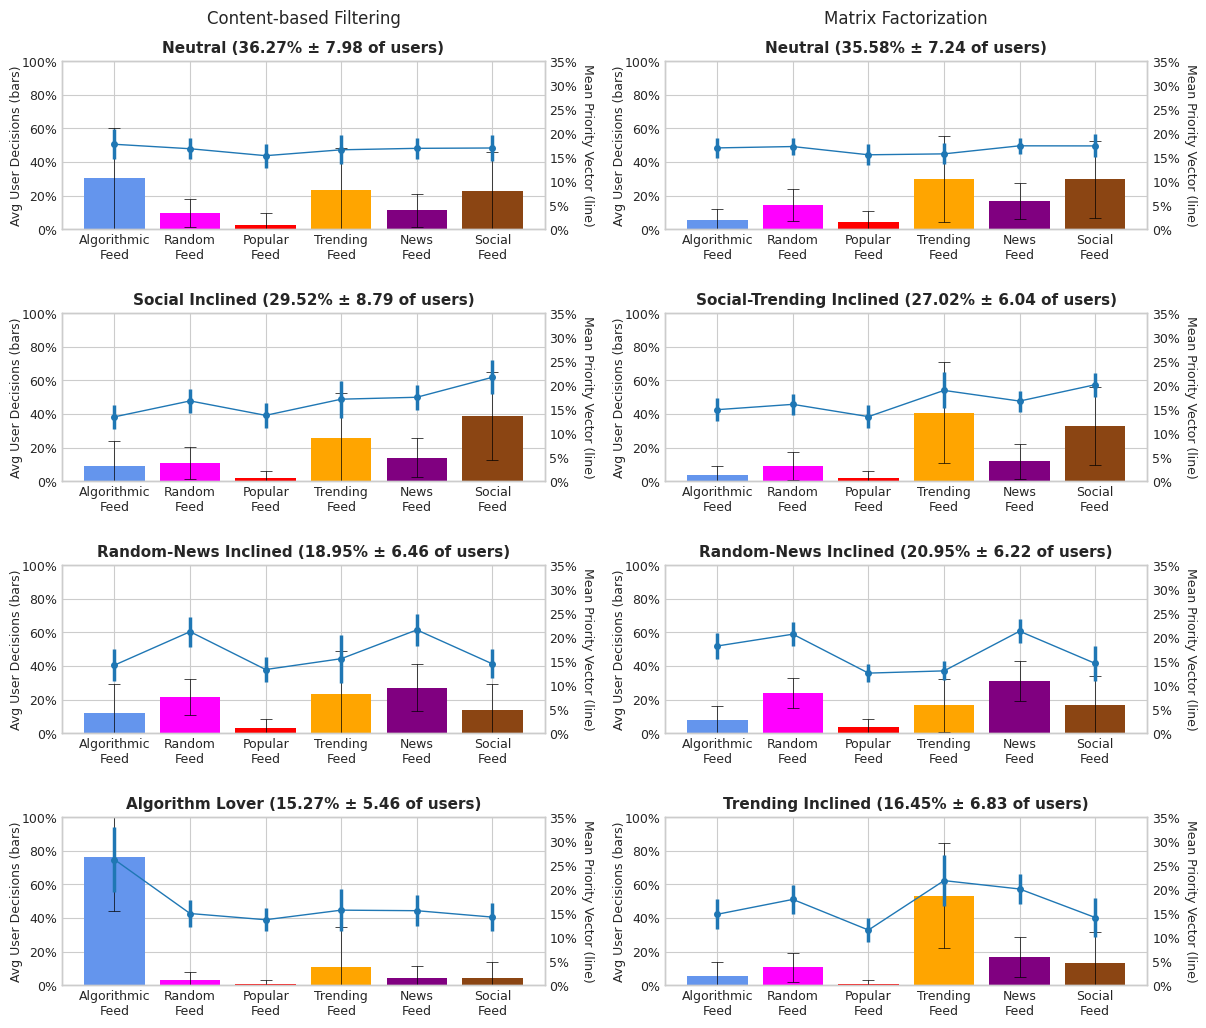

In [94]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(4, 2, figsize=(14, 12))  # 4 rows, 2 columns, (width x height)
fig.subplots_adjust(hspace=0.5, wspace=0.25)

col = -1
iter_index = last_iter -1
tot_utils = dict()
cluster_labels = dict()
cluster_names = dict()
cluster_mask = dict()


for mo in model_keys:
    col+=1
    tot_utils[mo] = dict()
    tot_utils[mo]["base"] = [base_utilities[mo].mean(), base_utilities[mo].std()]
    tot_utils[mo]["dynamic"] = [utilities[mo].mean(), utilities[mo].std()]

    tr = []
    ch = []
    ut = []
    ns = []
    cluster_labels[mo] = []
    for i in range(traits[mo].shape[0]):
        data = traits[mo][i,:,iter_index,:-1] # (users=200, traits=6)
        kmeans = KMeans(n_clusters = opt_k[mo], random_state=1234).fit(data)
        cluster_labels[mo].append(kmeans.labels_)
        tr_i = []
        ch_i = []
        ut_i = []
        ns_i = []
        for k in range(opt_k[mo]):
            traits_k = data[[cluster_labels[mo][i] == k]] # (users=cluster_users, traits=6)
            decisions_k = decisions[mo][i][[cluster_labels[mo][i] == k]][:,:iter_index+1] # (users=cluster_users, iters=180)
            utilities_k = utilities[mo][i][[cluster_labels[mo][i] == k]][:,:iter_index+1] # (users=cluster_users, iters=180)
            tr_i_k = np.array([traits_k.mean(axis=0), traits_k.std(axis=0)]).T # (traits=6, mean&std=2)
            cumulative_decisions_k = np.array([np.bincount(v, minlength=tr_i_k.shape[0])/decisions_k.shape[1] for v in decisions_k])
            ch_i_k = np.array([cumulative_decisions_k.mean(axis=0), cumulative_decisions_k.std(axis=0)]).T # (traits=6, mean&std=2)
            ut_i_k = np.array([utilities_k.mean(), utilities_k.std()]) # (mean&std=2)
            ns_i_k = (cluster_labels[mo][i] == k).sum() / cluster_labels[mo][i].shape[0]
            tr_i.append(tr_i_k)
            ch_i.append(ch_i_k)
            ut_i.append(ut_i_k)
            ns_i.append(ns_i_k)
        tr.append(tr_i)
        ch.append(ch_i)
        ut.append(ut_i)
        ns.append(ns_i)
    tr = np.array(tr)
    ch = np.array(ch)
    ut = np.array(ut)
    ns = np.array(ns)
    cluster_labels[mo] = np.array(cluster_labels[mo])

    reviews = 3
    nnn = np.zeros(tr.shape[0], dtype=bool)
    cluster_mask[mo] = np.ones((tr.shape[0], tr.shape[1]), dtype=int) * -1
    cluster_mask[mo][0] = np.arange(opt_k[mo])
    for _ in range(reviews):
        for i in range(tr.shape[0]):
            nnn[i] = False
            if nnn.any():
                testing_tr = np.concatenate([tr[nnn][:,:,:,0].reshape((-1,6)), tr[i][:,:,0]])
                mask_nnn = cluster_mask[mo][nnn].flatten()
                best_perm = np.arange(opt_k[mo])
                best_db = 1000.0
                for perm in permutations(np.arange(opt_k[mo])):
                    #print(tr[i][:,:,0])
                    p_db = davies_bouldin_score(testing_tr, np.append(mask_nnn, perm))
                    if p_db < best_db:
                        best_perm = perm
                        best_db = p_db
                cluster_mask[mo][i] = best_perm
            nnn[i] = True

    row = -1
    readable_feed_list = [feed_names_to_readable[feed].replace(" ", "\n") for feed in feed_names]
    cluster_order = {
        "content_5": [1,3,0,2],
        "mf": [2,1,0,3],
    }
    cluster_names = {
        "content_5": [
            "Random-News Inclined",
            "Neutral",
            "Algorithm Lover",
            "Social Inclined",
        ],
        "mf": [
            "Random-News Inclined",
            "Social-Trending Inclined",
            "Neutral",
            "Trending Inclined",
        ]
    }
    ax = axes[0, col]
    ax.text(
        x=2.5,
        y=1.2,
        s=model_to_readable[mo],
        ha='center',
        va='bottom', 
        fontsize=12,
    )
    for k in cluster_order[mo]:
        row += 1
        tr_k = tr[cluster_mask[mo] == k] # (sims=30, traits=6, mean&std=2)
        ch_k = ch[cluster_mask[mo] == k] # (sims=30, traits=6, mean&std=2)
        ut_k = ut[cluster_mask[mo] == k] # (sims=30, mean&std=2)
        ns_k = ns[cluster_mask[mo] == k] # (sims=30)

        ax = axes[row, col]
        ch_mean = ch_k.mean(axis=0)[:,0]
        ch_std = np.sqrt((ch_k[:,:,1]**2).mean(axis=0) + ch_k[:,:,0].var(axis=0))
        ax.bar(
            readable_feed_list,
            ch_mean,
            color=indexable_feed_colors,
            yerr=ch_std,
            error_kw={
                "elinewidth": 0.5,
                "capsize": 4,
                "capthick": 0.5
                },
            )
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
        ax.set_ylim((0.0, 1.0))
        ax.tick_params(axis='x', labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        ax.set_ylabel("Avg User Decisions (bars)", fontsize=9, labelpad=-1)

        ax2 = ax.twinx()
        tr_mean = tr_k.mean(axis=0)[:,0]
        tr_std = np.sqrt((tr_k[:,:,1]**2).mean(axis=0) + tr_k[:,:,0].var(axis=0))
        ax2.errorbar(
            readable_feed_list,
            tr_mean,
            color="tab:blue",
            marker="o",
            markersize=4,
            linewidth=1,
            yerr=tr_std,
            elinewidth=2.5,
            )
        ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x*100)}%"))
        ax2.set_ylim((0.0, 0.35))
        ax2.set_yticks(np.arange(0.0, 0.4, 0.05))
        ax2.tick_params(axis='y', labelsize=9)
        ax2.grid(False)
        ax2.set_ylabel("Mean Priority Vector (line)", rotation=270, fontsize=9, labelpad=12)

        ax.set_title(
            cluster_names[mo][k] 
            + " ("
            + str(np.round(ns_k.mean()*100,2))
            + "% ± "
            + str(np.round(ns_k.std()*100,2))
            + " of users)",
            fontweight="bold",
            fontsize=11,
        )
        ut_mean = ut_k[:,0].mean()
        ut_std = np.sqrt((ut_k[:,1]**2).mean(axis=0) + ut_k[:,0].var(axis=0))
        tot_utils[mo][cluster_names[mo][k]] = [ut_mean, ut_std]
fig.show()

In [146]:
def get_inter(s_u_i_a): # (sims=30, users=200, iters=180, attrs=20)
    s_u_a = s_u_i_a.mean(axis=2) # (sims=30, users=200, attrs=20)
    s_a = s_u_a.mean(axis=1) # (sims=30, attrs=20)
    s_u_d = np.linalg.norm(s_u_a - s_a[:,np.newaxis,:], axis=2) # (sims=30, users=200)
    inter = np.sqrt((s_u_d**2).sum(axis=1)/s_u_d.shape[1]) # (sims=30)
    return inter

def get_intra(s_u_i_a): # (sims=30, users=200, iters=180, attrs=20)
    s_u_a = s_u_i_a.mean(axis=2) # (sims=30, users=200, attrs=20)
    s_u_i_d = np.linalg.norm(s_u_i_a - s_u_a[:,:,np.newaxis,:], axis=3) # (sims=30, users=200, iters=180)
    intra = np.sqrt((s_u_i_d**2).sum(axis=2)/s_u_i_d.shape[2]).mean(axis=1) # (sims=30)
    return intra

def get_sim_homog_i(u_i_a, ideal_u_i_a, clst_labels=None, k_label=-1):
    u_a = u_i_a.mean(axis=1)
    pairs_p = get_sim_users_pairs(u_a)
    if not k_label == -1:
        pairs_p = pairs_p[(clst_labels[pairs_p]==k_label).any(axis=1)]
    pairs_p_i_a = u_i_a[pairs_p]
    ideal_pairs_p_i_a = ideal_u_i_a[pairs_p]
    pair_i_i_dist = []
    ideal_pair_i_i_dist = []
    for p in range(pairs_p_i_a.shape[0]):
        pair_i_i_dist.append(cdist(pairs_p_i_a[p, 0], pairs_p_i_a[p, 1], metric='euclidean'))
        ideal_pair_i_i_dist.append(cdist(ideal_pairs_p_i_a[p, 0], ideal_pairs_p_i_a[p, 1], metric='euclidean'))
    pair_i_i_dist = np.array(pair_i_i_dist)
    ideal_pair_i_i_dist = np.array(ideal_pair_i_i_dist)

    min_axis_0 = np.min(pair_i_i_dist, axis=2)
    min_axis_1 = np.min(pair_i_i_dist, axis=1)
    all_min_values = np.concatenate([min_axis_0.flatten(), min_axis_1.flatten()])
    chamfer_iter = np.mean(all_min_values)

    ideal_min_axis_0 = np.min(ideal_pair_i_i_dist, axis=2)
    ideal_min_axis_1 = np.min(ideal_pair_i_i_dist, axis=1)
    ideal_all_min_values = np.concatenate([ideal_min_axis_0.flatten(), ideal_min_axis_1.flatten()])
    ideal_chamfer_iter = np.mean(ideal_all_min_values)
    return ideal_chamfer_iter - chamfer_iter

def get_sim_homog(s_u_i_a, ideal_s_u_i_a):
    sim_homog = []
    for i in range(s_u_i_a.shape[0]):
        sim_homog.append(get_sim_homog_i(s_u_i_a[i], ideal_s_u_i_a[i]))
    sim_homog = np.array(sim_homog)
    return sim_homog

In [147]:
inter = dict()
intra = dict()
gen_homog = dict()
sim_homog = dict()

ideal_interactions = base_interactions["ideal"][:,:,:iter_index+1]
ideal_sims_user_iter_attr = np.transpose(
    np.array([item_attrs[i][:, ideal_interactions[i]] for i in range(item_attrs.shape[0])]),
    axes=[0,2,3,1],
)

for mo in model_keys:
    inter[mo] = dict()
    intra[mo] = dict()
    gen_homog[mo] = dict()
    sim_homog[mo] = dict()

    all_interactions = interactions[mo][:,:,:iter_index+1]
    all_base_interactions = base_interactions[mo][:,:,:iter_index+1]

    base_sims_user_iter_attr = np.transpose(
        np.array([base_item_attrs[i][:, all_base_interactions[i]] for i in range(base_item_attrs.shape[0])]),
        axes=[0,2,3,1],
    )
    sims_user_iter_attr = np.transpose(
        np.array([item_attrs[i][:, all_interactions[i]] for i in range(item_attrs.shape[0])]),
        axes=[0,2,3,1],
    )

    s_a = sims_user_iter_attr.mean(axis=2).mean(axis=1)

    base_inter = get_inter(base_sims_user_iter_attr)
    dyn_inter = get_inter(sims_user_iter_attr)
    base_intra = get_intra(base_sims_user_iter_attr)
    dyn_intra = get_intra(sims_user_iter_attr)
    inter[mo]["base"] = [base_inter.mean(), base_inter.std()]
    inter[mo]["dynamic"] = [dyn_inter.mean(), dyn_inter.std()]
    intra[mo]["base"] = [base_intra.mean(), base_intra.std()]
    intra[mo]["dynamic"] = [dyn_intra.mean(), dyn_intra.std()]
    base_homog = (base_inter**2 + base_intra**2)**(-0.5)
    dyn_homog = (dyn_inter**2 + dyn_intra**2)**(-0.5)
    gen_homog[mo]["base"] = [base_homog.mean(), base_homog.std()]
    gen_homog[mo]["dynamic"] = [dyn_homog.mean(), dyn_homog.std()]
    base_sim_homog = get_sim_homog(base_sims_user_iter_attr, ideal_sims_user_iter_attr)
    dyn_sim_homog = get_sim_homog(sims_user_iter_attr, ideal_sims_user_iter_attr)
    sim_homog[mo]["base"] = [base_sim_homog.mean(), base_sim_homog.std()]
    sim_homog[mo]["dynamic"] = [dyn_sim_homog.mean(), dyn_sim_homog.std()]

    inter_per_cluster = []
    intra_per_cluster = []
    gen_homog_per_cluster = []
    sim_homog_per_cluster = []
    for i in range(sims_user_iter_attr.shape[0]):
        k_inter = []
        k_intra = []
        k_gen_homog = []
        k_sim_homog = []
        for k in range(opt_k[mo]):
            k_users_iter_attrs = sims_user_iter_attr[i][cluster_labels[mo][i] == k]
            k_users_attrs = k_users_iter_attrs.mean(axis=1)
            #k_attrs = k_users_attrs.mean(axis=0)
            k_users_dist = np.linalg.norm(k_users_attrs - s_a[i,np.newaxis,:], axis=1) # cambiar s_a[i] por k_attrs pa cachar ==> es lo mismo pero los valores de k_attrs son más chicos
            k_inter.append(np.sqrt((k_users_dist**2).sum()/k_users_dist.shape[0]))
            k_users_iters_dist = np.linalg.norm(k_users_iter_attrs - k_users_attrs[:,np.newaxis,:], axis=2)
            k_intra.append(np.sqrt((k_users_iters_dist**2).sum(axis=1)/k_users_iters_dist.shape[1]).mean())
            k_gen_homog.append((k_inter[-1]**2 + k_intra[-1]**2)**(-0.5))
            k_sim_homog.append(get_sim_homog_i(
                sims_user_iter_attr[i],
                ideal_sims_user_iter_attr[i],
                clst_labels=cluster_labels[mo][i],
                k_label=k,
            ))
        inter_per_cluster.append(k_inter)
        intra_per_cluster.append(k_intra)
        gen_homog_per_cluster.append(k_gen_homog)
        sim_homog_per_cluster.append(k_sim_homog)
    inter_per_cluster = np.array(inter_per_cluster)
    intra_per_cluster = np.array(intra_per_cluster)
    gen_homog_per_cluster = np.array(gen_homog_per_cluster)
    sim_homog_per_cluster = np.array(sim_homog_per_cluster)

    for k in cluster_order[mo]:
        meta_clst_inter = inter_per_cluster[cluster_mask[mo] == k]
        meta_clst_intra = intra_per_cluster[cluster_mask[mo] == k]
        meta_clst_gen_homog = gen_homog_per_cluster[cluster_mask[mo] == k]
        meta_clst_sim_homog = sim_homog_per_cluster[cluster_mask[mo] == k]
        inter[mo][cluster_names[mo][k]] = [meta_clst_inter.mean(), meta_clst_inter.std()]
        intra[mo][cluster_names[mo][k]] = [meta_clst_intra.mean(), meta_clst_inter.std()]
        gen_homog[mo][cluster_names[mo][k]] = [meta_clst_gen_homog.mean(), meta_clst_gen_homog.std()]
        sim_homog[mo][cluster_names[mo][k]] = [meta_clst_sim_homog.mean(), meta_clst_sim_homog.std()]

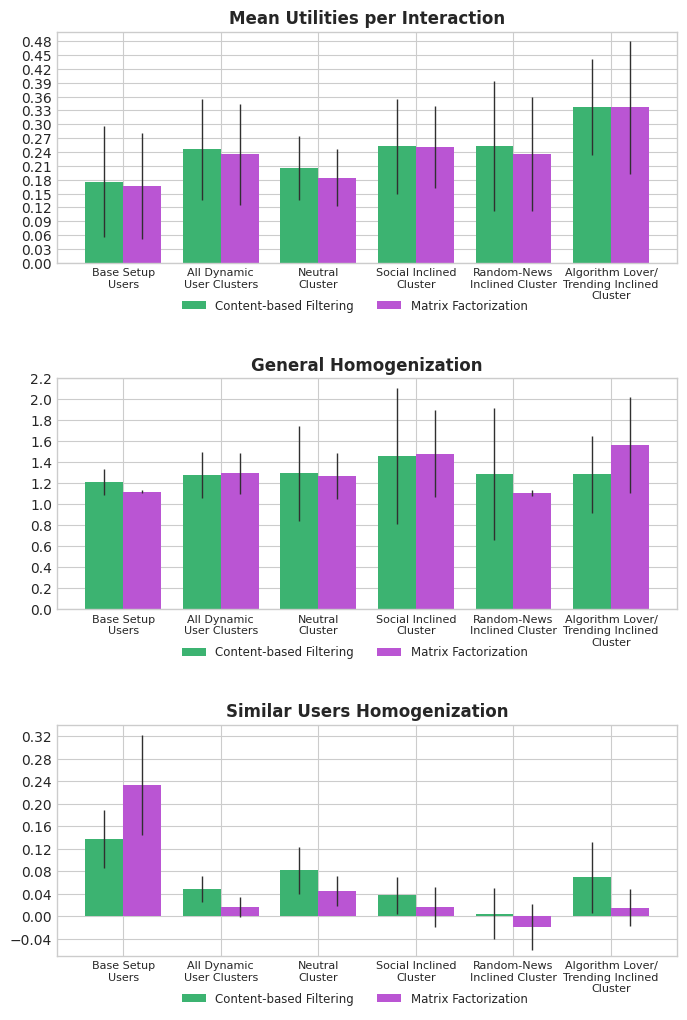

In [163]:
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(3, 1, figsize=(8, 12))  # 3 rows, 1 columns, (width x height)
fig.subplots_adjust(hspace=0.5, wspace=0.25)

cluster_bar_readable = {
    "base": "Base Setup\nUsers",
    "dynamic": "All Dynamic\nUser Clusters",
    "neutral": "Neutral\nCluster",
    "social": "Social Inclined\nCluster",
    "random": "Random-News\nInclined Cluster",
    "algotrend": "Algorithm Lover/\nTrending Inclined\nCluster",
    }
cluster_bar_colors = {
    "base": "cornflowerblue",
    "dynamic": "indianred",
    "neutral": "darkgrey",
    "social": "saddlebrown",
    "random": "palevioletred",
    "algotrend": "darkseagreen",
    }
cluster_bar_labels = list(cluster_bar_readable.values())
x = np.arange(0.0, 5.0, 0.9)
col = -0.175
for mo in model_keys:
    ax=axes[0]
    ax.bar(
        x + col,
        np.array(list(tot_utils[mo].values()))[:,0],
        0.35,
        color=rs_colors[mo],
        yerr=np.array(list(tot_utils[mo].values()))[:,1],
        error_kw={
            "elinewidth": 1.,
            "ecolor": "#303030",
            },
        label=model_to_readable[mo],
        )
    ax.set_yticks(np.arange(0.0, 0.6, 0.03))
    ax.set_ylim((0.0, 0.5))
    ax.legend(loc='lower center', bbox_to_anchor=(0.48, -0.26), ncol=6, fontsize=8.5)
    ax.set_title("Mean Utilities per Interaction", fontweight="bold")
    ax.set_xticks(x, cluster_bar_labels, fontsize=8.0)

    ax=axes[1]
    ax.bar(
        x + col,
        np.array(list(gen_homog[mo].values()))[:,0],
        0.35,
        color=rs_colors[mo],
        yerr=np.array(list(gen_homog[mo].values()))[:,1],
        error_kw={
            "elinewidth": 1.,
            "ecolor": "#303030",
            },
        label=model_to_readable[mo],
        )
    ax.set_yticks(np.arange(0.0, 2.4, 0.2))
    ax.set_ylim((0.0, 2.2))
    ax.legend(loc='lower center', bbox_to_anchor=(0.48, -0.26), ncol=6, fontsize=8.5)
    ax.set_title("General Homogenization", fontweight="bold")
    ax.set_xticks(x, cluster_bar_labels, fontsize=8.0)

    ax=axes[2]
    ax.bar(
        x + col,
        np.array(list(sim_homog[mo].values()))[:,0],
        0.35,
        color=rs_colors[mo],
        yerr=np.array(list(sim_homog[mo].values()))[:,1],
        error_kw={
            "elinewidth": 1.,
            "ecolor": "#303030",
            },
        label=model_to_readable[mo],
        )
    ax.set_yticks(np.arange(-0.08, 0.4, 0.04))
    ax.set_ylim((-0.07, 0.34))
    ax.legend(loc='lower center', bbox_to_anchor=(0.48, -0.26), ncol=6, fontsize=8.5)
    ax.set_title("Similar Users Homogenization", fontweight="bold")
    ax.set_xticks(x, cluster_bar_labels, fontsize=8.0)
    
    col+=0.35
plt.show()